<a href="https://colab.research.google.com/github/ishuu9837/temp/blob/main/Abnormal_Learning_Behaviour_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('/content/features_df.csv')
print(df.shape)
print(df.columns.tolist())
df.head(3)

(1029, 13)
['roll_no', 'name', 'pseudocode_attendance_rate', 'pseudocode_avg_score', 'coding_practice_solved_pct', 'coding_test_overall_score', 'coding_test_attendance', 'weekly_score_consistency', 'practice_problems_solved', 'weeks_zero_activity', 'anomaly_score', 'is_anomaly', 'severity']


,roll_no,name,pseudocode_attendance_rate,pseudocode_avg_score,coding_practice_solved_pct,coding_test_overall_score,coding_test_attendance,weekly_score_consistency,practice_problems_solved,weeks_zero_activity,anomaly_score,is_anomaly,severity
0,2023001753,Padamati Navdeep Goud,43.33,80.00,0.0,86.67,2.0,65.6,12.9,0,0.068583,False,LOW
1,2023001493,B Vishwajanani,43.33,46.67,45.0,46.67,2.4,53.8,15.4,0,0.021085,False,LOW
2,2023001843,Aasmitha Malavika Joshi,53.33,86.67,0.0,53.33,2.4,40.8,15.4,0,0.050939,False,LOW


In [3]:
np.random.seed(42)

FEATURE_NAMES = [
    'pseudocode_attendance_rate',
    'pseudocode_avg_score',
    'coding_practice_solved_pct',
    'coding_test_overall_score',
    'coding_test_attendance',
    'weekly_score_consistency',
    'practice_problems_solved',
    'weeks_zero_activity',
]

print(f' Dataset loaded: {df.shape}')
print(f'   Normal    : {(~df.is_anomaly).sum()}')
print(f'   Anomalous : {(df.is_anomaly).sum()}')

 Dataset loaded: (1029, 13)
   Normal    : 978
   Anomalous : 51


In [4]:
class DeepAutoencoder:
    def __init__(self):
        self.input_dim  = 8
        self.latent_dim = 4
        self.scaler     = MinMaxScaler()
        self.threshold  = None
        np.random.seed(42)
        self.W_enc = np.random.randn(self.input_dim, self.latent_dim) * 0.3
        self.b_enc = np.zeros(self.latent_dim)
        self.W_dec = np.random.randn(self.latent_dim, self.input_dim) * 0.3
        self.b_dec = np.zeros(self.input_dim)

    def _relu(self, x):    return np.maximum(0, x)
    def _sigmoid(self, x): return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    def _encode(self, x):  return self._relu(x @ self.W_enc + self.b_enc)
    def _decode(self, z):  return self._sigmoid(z @ self.W_dec + self.b_dec)
    def _forward(self, x): return self._decode(self._encode(x))

    def train(self, X_raw):
        Xs = self.scaler.fit_transform(X_raw)
        lr = 0.01
        for epoch in range(500):
            z     = self._encode(Xs)
            x_hat = self._decode(z)
            err   = x_hat - Xs
            ds    = x_hat * (1 - x_hat)
            dd    = err * ds
            self.W_dec -= lr * (z.T @ dd)  / len(Xs)
            self.b_dec -= lr * dd.mean(0)
            de = (dd @ self.W_dec.T) * (z > 0)
            self.W_enc -= lr * (Xs.T @ de) / len(Xs)
            self.b_enc -= lr * de.mean(0)

        errs = np.mean((Xs - self._forward(Xs))**2, axis=1)

        # ── THRESHOLD CONTROL ──────────────────────────────────────────
        # Change percentile → controls how many students enter anomaly zone
        #   90 = top 10% flagged  |  95 = top 5%  |  99 = top 1%
        self.threshold = float(np.percentile(errs, 90))   # ← CHANGE HERE
        # ───────────────────────────────────────────────────────────────

        print(f' Trained | Base Threshold (90th pct) : {self.threshold:.6f}')
        print(f'          Medium cutoff (1.0x)        : {self.threshold * 1.0:.6f}')
        print(f'          High   cutoff (2.0x)        : {self.threshold * 2.0:.6f}')

    def predict(self, raw: dict) -> dict:
        x   = np.array([[raw.get(f, 0) for f in FEATURE_NAMES]], dtype=float)
        xs  = self.scaler.transform(x)
        xh  = self._forward(xs)
        sc  = float(np.mean((xs - xh) ** 2))
        fe  = {f: float(e) for f, e in zip(FEATURE_NAMES, (xs[0] - xh[0]) ** 2)}
        top = sorted(fe.items(), key=lambda v: v[1], reverse=True)[:3]

        # ── SEVERITY CONTROL ───────────────────────────────────────────
        # HIGH   : score > threshold * 2.0  ← CHANGE 2.0 to adjust HIGH cutoff
        # MEDIUM : score > threshold * 1.0  ← CHANGE 1.0 to adjust MEDIUM cutoff
        if sc > self.threshold * 2.0:      # ← CHANGE HIGH multiplier here
            sev        = 'HIGH'
            is_anomaly = True
        elif sc > self.threshold * 1.0:    # ← CHANGE MEDIUM multiplier here
            sev        = 'MEDIUM'
            is_anomaly = True
        else:
            sev        = 'NORMAL'
            is_anomaly = False
        # ───────────────────────────────────────────────────────────────

        return {
            'anomaly_score': round(sc, 6),
            'threshold':     round(self.threshold, 6),
            'is_anomaly':    is_anomaly,
            'severity':      sev,
            'top_features':  top,
        }

print(' Model class ready')

 Model class ready


In [5]:
X_normal = df[~df.is_anomaly][FEATURE_NAMES].values.astype(float)

print(f'Training on {len(X_normal)} normal students...')
model = DeepAutoencoder()
model.train(X_normal)

Training on 978 normal students...
 Trained | Base Threshold (90th pct) : 0.084085
          Medium cutoff (1.0x)        : 0.084085
          High   cutoff (2.0x)        : 0.168171


In [6]:
X_normal = df[~df.is_anomaly][FEATURE_NAMES].values.astype(float)

print(f'Training on {len(X_normal)} normal students...')
model = DeepAutoencoder()
model.train(X_normal)

Training on 978 normal students...
 Trained | Base Threshold (90th pct) : 0.084085
          Medium cutoff (1.0x)        : 0.084085
          High   cutoff (2.0x)        : 0.168171


In [7]:
scores, is_anom, sevs = [], [], []

for _, row in df.iterrows():
    raw = {f: row[f] for f in FEATURE_NAMES}
    r   = model.predict(raw)
    scores.append(r['anomaly_score'])
    is_anom.append(r['is_anomaly'])
    sevs.append(r['severity'])

df['pred_score']    = scores
df['pred_anomaly']  = is_anom
df['pred_severity'] = sevs

print(f'\n Results:')
print(f'   Total         : {len(df)}')
print(f'   Normal        : {(df.pred_severity == "NORMAL").sum()}')
print(f'   Medium Risk   : {(df.pred_severity == "MEDIUM").sum()}')
print(f'   High Risk     : {(df.pred_severity == "HIGH").sum()}')
print(f'   Total Flagged : {df.pred_anomaly.sum()}')


 Results:
   Total         : 1029
   Normal        : 881
   Medium Risk   : 145
   High Risk     : 3
   Total Flagged : 148


In [8]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

y_true  = df.is_anomaly.astype(int)
y_pred  = df.pred_anomaly.astype(int)
y_score = df.pred_score

acc   = (y_true == y_pred).mean() * 100
f1    = f1_score(y_true, y_pred) * 100
auc   = roc_auc_score(y_true, y_score) * 100
prec  = (y_true[y_pred==1] == 1).mean() * 100 if y_pred.sum() > 0 else 0
rec   = (y_pred[y_true==1] == 1).mean() * 100

print('='*45)
print('      MODEL ACCURACY REPORT')
print('='*45)
print(f'  Accuracy         : {acc:.2f}%')
print(f'  Precision        : {prec:.2f}%')
print(f'  Recall           : {rec:.2f}%')
print(f'  F1 Score         : {f1:.2f}%')
print(f'  ROC-AUC          : {auc:.2f}%')
print(f'  Threshold        : {model.threshold:.6f}')
print('='*45)
print()
print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomalous']))

      MODEL ACCURACY REPORT
  Accuracy         : 90.38%
  Precision        : 33.78%
  Recall           : 98.04%
  F1 Score         : 50.25%
  ROC-AUC          : 98.32%
  Threshold        : 0.084085

              precision    recall  f1-score   support

      Normal       1.00      0.90      0.95       978
   Anomalous       0.34      0.98      0.50        51

    accuracy                           0.90      1029
   macro avg       0.67      0.94      0.72      1029
weighted avg       0.97      0.90      0.92      1029



In [9]:
X_all        = df[FEATURE_NAMES].values.astype(float)
X_all_scaled = model.scaler.transform(X_all)
X_all_recon  = model._forward(X_all_scaled)

recon_errors = np.mean((X_all_scaled - X_all_recon) ** 2, axis=1)
df['recon_error'] = recon_errors

feature_errors   = (X_all_scaled - X_all_recon) ** 2
feature_error_df = pd.DataFrame(feature_errors, columns=[f'err_{f}' for f in FEATURE_NAMES])
df = pd.concat([df.reset_index(drop=True), feature_error_df.reset_index(drop=True)], axis=1)

effective_threshold_medium = model.threshold * 1.0
effective_threshold_high   = model.threshold * 2.0

print('='*55)
print('        RECONSTRUCTION ERROR SUMMARY')
print('='*55)
print(f'  Base Threshold (90th pct)   : {model.threshold:.6f}')
print(f'  Medium Cutoff (1.0x)        : {effective_threshold_medium:.6f}')
print(f'  High   Cutoff (2.0x)        : {effective_threshold_high:.6f}')
print(f'  Mean Recon Error (Normal)   : {df[~df.is_anomaly]["recon_error"].mean():.6f}')
print(f'  Mean Recon Error (Anomaly)  : {df[df.is_anomaly]["recon_error"].mean():.6f}')
print(f'  Max Recon Error             : {df["recon_error"].max():.6f}')
print(f'  Min Recon Error             : {df["recon_error"].min():.6f}')
print('='*55)
df[['recon_error', 'pred_score', 'pred_severity']].describe()

        RECONSTRUCTION ERROR SUMMARY
  Base Threshold (90th pct)   : 0.084085
  Medium Cutoff (1.0x)        : 0.084085
  High   Cutoff (2.0x)        : 0.168171
  Mean Recon Error (Normal)   : 0.060858
  Mean Recon Error (Anomaly)  : 0.118897
  Max Recon Error             : 0.227239
  Min Recon Error             : 0.017268


,recon_error,pred_score
count,1029.000000,1029.000000
mean,0.063734,0.063734
std,0.021190,0.021190
min,0.017268,0.017268
25%,0.049959,0.049959
50%,0.059765,0.059765
75%,0.073803,0.073803
max,0.227239,0.227239


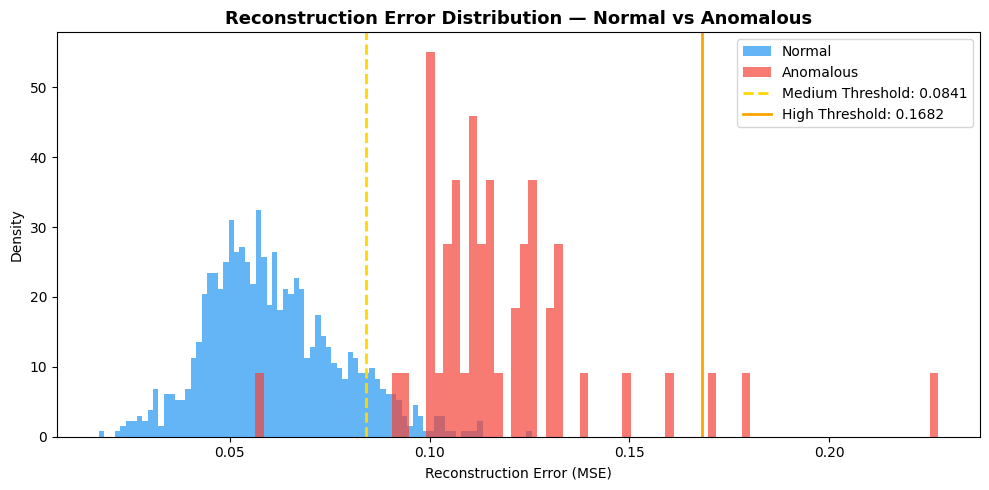

✅ Plot 1 saved


In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df[~df.is_anomaly]['recon_error'],
        bins=80, alpha=0.7, color='#2196F3', label='Normal', density=True)
ax.hist(df[df.is_anomaly]['recon_error'],
        bins=80, alpha=0.7, color='#F44336', label='Anomalous', density=True)
ax.axvline(effective_threshold_medium, color='gold', linewidth=2,
           linestyle='--', label=f'Medium Threshold: {effective_threshold_medium:.4f}')
ax.axvline(effective_threshold_high, color='orange', linewidth=2,
           linestyle='-', label=f'High Threshold: {effective_threshold_high:.4f}')

ax.set_title('Reconstruction Error Distribution — Normal vs Anomalous', fontsize=13, fontweight='bold')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('plot1_recon_error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot 1 saved')

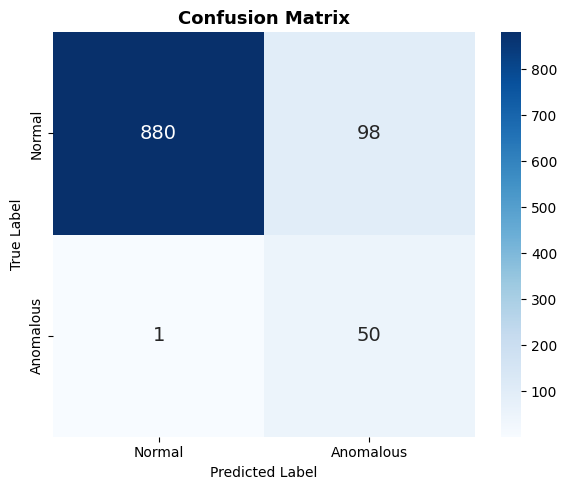

✅ Plot 2 saved


In [11]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Anomalous'],
            yticklabels=['Normal', 'Anomalous'],
            annot_kws={"size": 14})

ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('plot2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot 2 saved')

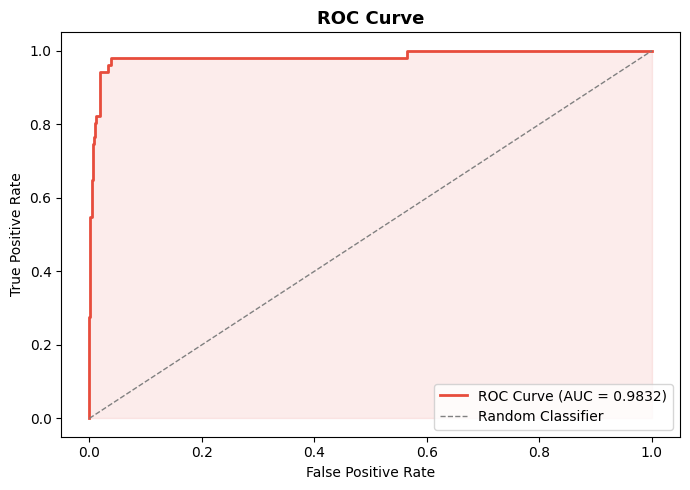

✅ Plot 3 saved


In [12]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_true, y_score)
auc_val     = roc_auc_score(y_true, y_score)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'ROC Curve (AUC = {auc_val:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')

ax.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plot3_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot 3 saved')

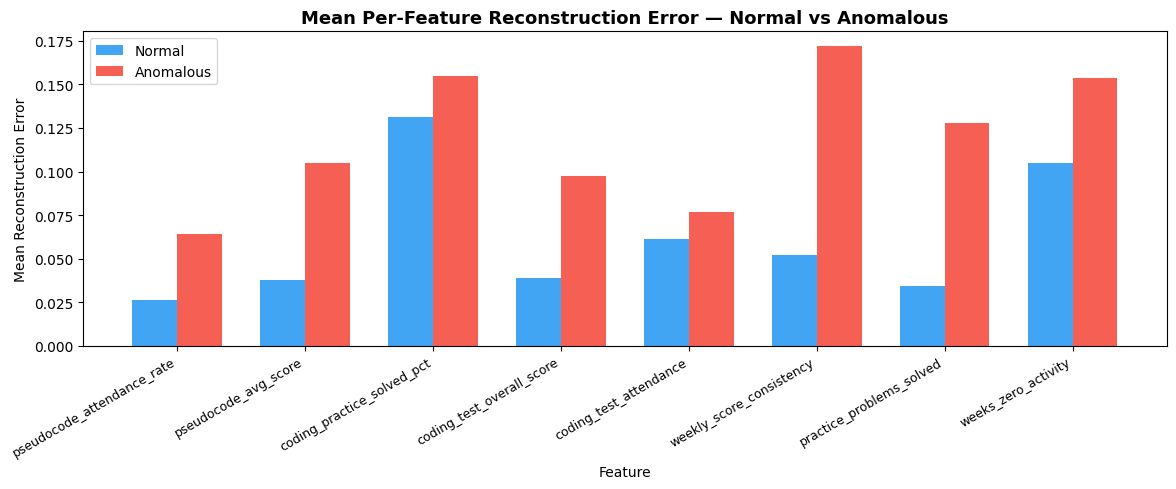

✅ Plot 4 saved


In [13]:
feature_err_cols = [f'err_{f}' for f in FEATURE_NAMES]

mean_err_normal  = df[~df.is_anomaly][feature_err_cols].mean()
mean_err_anomaly = df[df.is_anomaly][feature_err_cols].mean()

x     = np.arange(len(FEATURE_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x - width/2, mean_err_normal.values,  width, label='Normal',    color='#2196F3', alpha=0.85)
ax.bar(x + width/2, mean_err_anomaly.values, width, label='Anomalous', color='#F44336', alpha=0.85)

ax.set_title('Mean Per-Feature Reconstruction Error — Normal vs Anomalous', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Mean Reconstruction Error')
ax.set_xticks(x)
ax.set_xticklabels(FEATURE_NAMES, rotation=30, ha='right', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig('plot4_feature_recon_error.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot 4 saved')

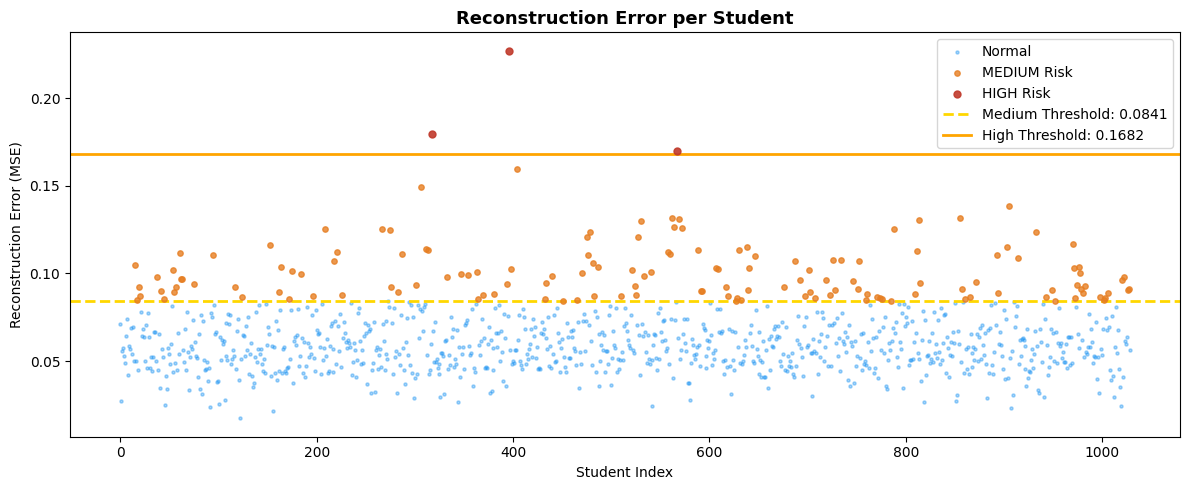

✅ Plot 5 saved


In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

normal_idx  = df[df.pred_severity == 'NORMAL'].index
medium_idx  = df[df.pred_severity == 'MEDIUM'].index
high_idx    = df[df.pred_severity == 'HIGH'].index

ax.scatter(normal_idx, df.loc[normal_idx, 'recon_error'],
           s=5,  alpha=0.4, color='#2196F3', label='Normal')
ax.scatter(medium_idx, df.loc[medium_idx, 'recon_error'],
           s=15, alpha=0.8, color='#e67e22', label='MEDIUM Risk', zorder=4)
ax.scatter(high_idx,   df.loc[high_idx,   'recon_error'],
           s=25, alpha=0.9, color='#c0392b', label='HIGH Risk',   zorder=5)
ax.axhline(effective_threshold_medium, color='gold',   linewidth=2,
           linestyle='--', label=f'Medium Threshold: {effective_threshold_medium:.4f}')
ax.axhline(effective_threshold_high,   color='orange', linewidth=2,
           linestyle='-',  label=f'High Threshold: {effective_threshold_high:.4f}')

ax.set_title('Reconstruction Error per Student', fontsize=13, fontweight='bold')
ax.set_xlabel('Student Index')
ax.set_ylabel('Reconstruction Error (MSE)')
ax.legend()
plt.tight_layout()
plt.savefig('plot5_student_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot 5 saved')

In [15]:
with open('autoencoder_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print('✅ Model saved!')
print(f'   Location  : /content/autoencoder_model.pkl')
print(f'   Threshold : {model.threshold:.6f}')
print(f'   Medium Cutoff (1.0x) : {model.threshold * 1.0:.6f}')
print(f'   High   Cutoff (2.0x) : {model.threshold * 2.0:.6f}')

from google.colab import files
files.download('autoencoder_model.pkl')

✅ Model saved!
   Location  : /content/autoencoder_model.pkl
   Threshold : 0.084085
   Medium Cutoff (1.0x) : 0.084085
   High   Cutoff (2.0x) : 0.168171


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>